In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statistics as st
from scipy.stats import skew, kurtosis, ttest_ind, mannwhitneyu, kruskal, shapiro, anderson, ttest_ind, f_oneway
from scipy.signal import find_peaks

In [2]:
df = pd.read_csv('mercedes_benz_sales_2020_2025.csv')
df.head()

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo
0,A-Class,2020,Global,Yellow,Diesel,41265,252,1,Yes
1,A-Class,2020,Global,Black,Petrol,51023,249,1,No
2,A-Class,2020,Global,Grey,Petrol,72819,341,1,Yes
3,A-Class,2020,Global,Black,Petrol,62480,385,1,Yes
4,A-Class,2020,Global,White,Petrol,35189,337,1,Yes


In [3]:
df.shape

(12132666, 9)

In [4]:
df.isnull().sum()

Model               0
Year                0
Region              0
Color               0
Fuel Type           0
Base Price (USD)    0
Horsepower          0
Sales Volume        0
Turbo               0
dtype: int64

In [5]:
df.duplicated().sum()

3153

In [6]:
df[df.duplicated(keep=False)]

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo
1214,A-Class,2020,Global,Silver,Petrol,49516,241,1,Yes
2904,A-Class,2020,Global,White,Petrol,65885,262,1,Yes
3196,A-Class,2020,Global,White,Petrol,78786,395,1,Yes
3415,A-Class,2020,Global,White,Petrol,65885,262,1,Yes
3765,A-Class,2020,Global,Grey,Petrol,68945,212,1,Yes
...,...,...,...,...,...,...,...,...,...
12100718,AMG A 45,2025,Global,Black,Electric,382984,412,1,Yes
12108045,AMG C 63,2025,Global,White,Hybrid,380956,494,1,Yes
12115250,AMG C 63,2025,Global,White,Hybrid,380956,494,1,Yes
12127590,AMG S 63,2025,Global,Grey,Electric,311675,796,1,Yes


In [7]:
df['Sales'] = df['Base Price (USD)'] * df['Sales Volume']
df.head()

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo,Sales
0,A-Class,2020,Global,Yellow,Diesel,41265,252,1,Yes,41265
1,A-Class,2020,Global,Black,Petrol,51023,249,1,No,51023
2,A-Class,2020,Global,Grey,Petrol,72819,341,1,Yes,72819
3,A-Class,2020,Global,Black,Petrol,62480,385,1,Yes,62480
4,A-Class,2020,Global,White,Petrol,35189,337,1,Yes,35189


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12132666 entries, 0 to 12132665
Data columns (total 10 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   Model             object
 1   Year              int64 
 2   Region            object
 3   Color             object
 4   Fuel Type         object
 5   Base Price (USD)  int64 
 6   Horsepower        int64 
 7   Sales Volume      int64 
 8   Turbo             object
 9   Sales             int64 
dtypes: int64(5), object(5)
memory usage: 925.6+ MB


In [9]:
df['Year'] = pd.to_datetime(df['Year'], format='%Y').dt.year

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12132666 entries, 0 to 12132665
Data columns (total 10 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   Model             object
 1   Year              int32 
 2   Region            object
 3   Color             object
 4   Fuel Type         object
 5   Base Price (USD)  int64 
 6   Horsepower        int64 
 7   Sales Volume      int64 
 8   Turbo             object
 9   Sales             int64 
dtypes: int32(1), int64(4), object(5)
memory usage: 879.4+ MB


##### 1. Data consists of 12,132,666 rows and 9 columns<br>2. There are 1 column of date format, 4 columns are numbers and 5 columns are strings<br>3. There no missing values detected<br>4. Duplicated value detected but the value are different

In [11]:
df.head()

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo,Sales
0,A-Class,2020,Global,Yellow,Diesel,41265,252,1,Yes,41265
1,A-Class,2020,Global,Black,Petrol,51023,249,1,No,51023
2,A-Class,2020,Global,Grey,Petrol,72819,341,1,Yes,72819
3,A-Class,2020,Global,Black,Petrol,62480,385,1,Yes,62480
4,A-Class,2020,Global,White,Petrol,35189,337,1,Yes,35189


In [12]:
dflr = df.copy()

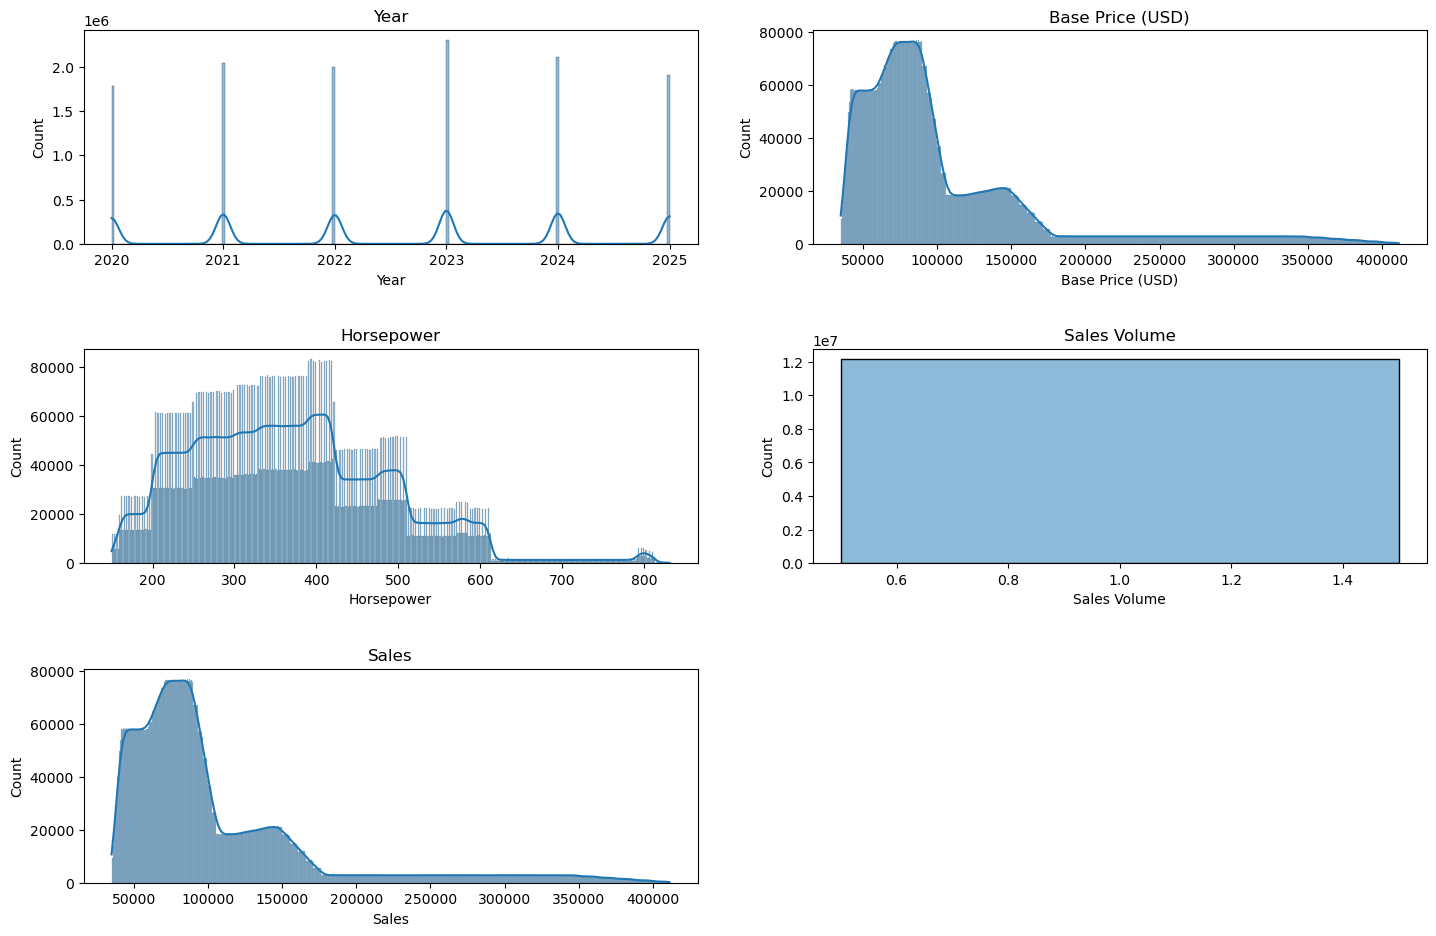

In [13]:
num_cols = dflr.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3,2,i)
    sns.histplot(dflr[col], kde=True)
    plt.title(f'{col}')

plt.tight_layout(pad=3)
plt.show()

Text(0.5, 1.0, 'Sales')

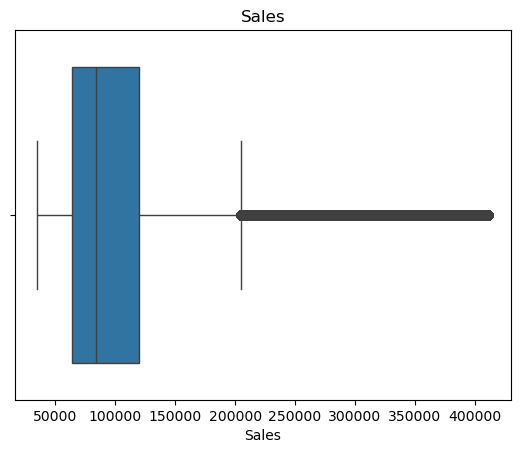

In [14]:
sns.boxplot(x = dflr['Sales'])
plt.title('Sales')

In [15]:
dflr[num_cols].skew()

Year               -0.044999
Base Price (USD)    2.156508
Horsepower          0.620531
Sales Volume        0.000000
Sales               2.156508
dtype: float64

##### 1. From the distribution, mostly are not normal<br>2. Base price and sales are the same column, so we drop Base price column to avoid redundant.<br>3. Sales volume is discrete data type and Year column is a Year data type<br>4 Only Sales column are valid for the distribution and since it's a right tail skew, we will using boxcox method because skew is more than two. Besides, Sales column is the target variable and want using Linear Regression as model to predict the sales

In [16]:
dflr['Sales_log'] = np.log1p(df['Sales'])

<Axes: xlabel='Sales_log'>

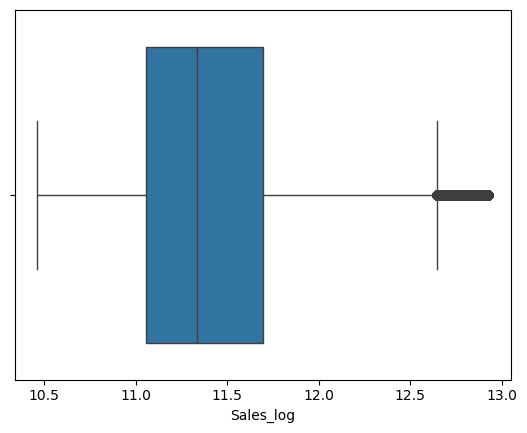

In [17]:
sns.boxplot(x = dflr['Sales_log'])

<Axes: xlabel='Sales_log', ylabel='Count'>

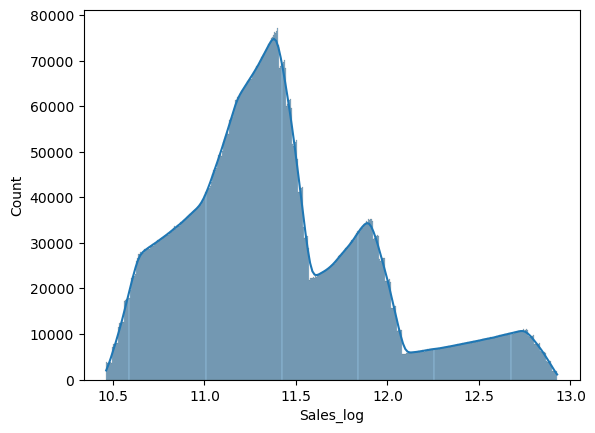

In [18]:
sns.histplot(dflr['Sales_log'], kde=True)

##### We Log Transform Sales by create new column which is Sales_log

In [19]:
dflr.head()

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo,Sales,Sales_log
0,A-Class,2020,Global,Yellow,Diesel,41265,252,1,Yes,41265,10.627794
1,A-Class,2020,Global,Black,Petrol,51023,249,1,No,51023,10.840051
2,A-Class,2020,Global,Grey,Petrol,72819,341,1,Yes,72819,11.195746
3,A-Class,2020,Global,Black,Petrol,62480,385,1,Yes,62480,11.042618
4,A-Class,2020,Global,White,Petrol,35189,337,1,Yes,35189,10.468517


In [20]:
dflr.describe(include='all')

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo,Sales,Sales_log
count,12132666,1.213267e+07,12132666,12132666,12132666,1.213267e+07,1.213267e+07,12132666.0,12132666,1.213267e+07,1.213267e+07
unique,17,NaN,1,10,4,NaN,NaN,NaN,2,NaN,NaN
top,GLC,NaN,Global,Black,Petrol,NaN,NaN,NaN,Yes,NaN,NaN
freq,2091045,NaN,12132666,3031663,5821366,NaN,NaN,NaN,10371297,NaN,NaN
mean,NaN,2.022548e+03,NaN,NaN,NaN,1.042169e+05,3.674594e+02,1.0,NaN,1.042169e+05,1.140458e+01
std,NaN,1.658896e+00,NaN,NaN,NaN,6.783388e+04,1.195446e+02,0.0,NaN,6.783388e+04,5.138309e-01
min,NaN,2.020000e+03,NaN,NaN,NaN,3.500000e+04,1.500000e+02,1.0,NaN,3.500000e+04,1.046313e+01
25%,NaN,2.021000e+03,NaN,NaN,NaN,6.346200e+04,2.750000e+02,1.0,NaN,6.346200e+04,1.105821e+01
50%,NaN,2.023000e+03,NaN,NaN,NaN,8.357200e+04,3.580000e+02,1.0,NaN,8.357200e+04,1.133348e+01
75%,NaN,2.024000e+03,NaN,NaN,NaN,1.199200e+05,4.440000e+02,1.0,NaN,1.199200e+05,1.169459e+01


<Axes: xlabel='Horsepower', ylabel='Sales'>

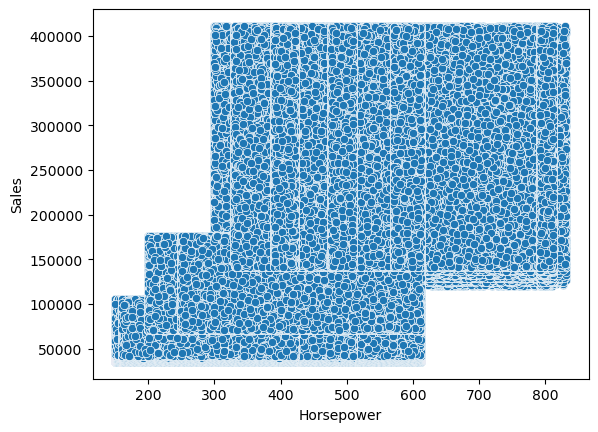

In [21]:
sns.scatterplot(x=dflr['Horsepower'], y=dflr['Sales'])

In [22]:
dflr['Base_Price_log'] = np.log1p(df['Base Price (USD)'])

In [23]:
dflr['hp_log'] = np.log1p(df['Horsepower'])

In [24]:
corr = dflr[['Base_Price_log', 'hp_log']].corr()
corr

,Base_Price_log,hp_log
Base_Price_log,1.000000,0.400752
hp_log,0.400752,1.000000


<Axes: xlabel='hp_log', ylabel='Base_Price_log'>

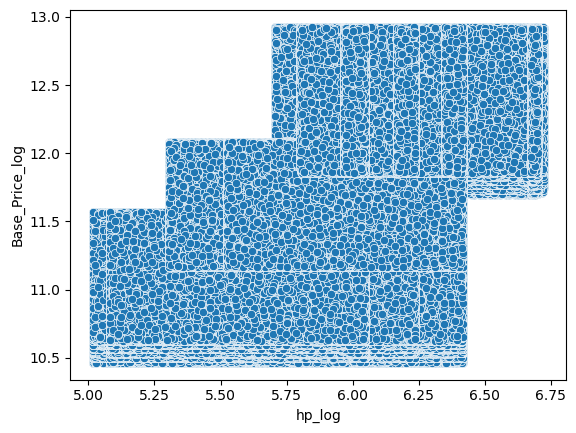

In [25]:
sns.scatterplot(x=dflr['hp_log'], y=dflr['Base_Price_log'])

In [26]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# pilih features
X = dflr[['hp_log', 'Base_Price_log' , 'Sales_log']]

# tambah constant (WAJIB untuk VIF)
X = sm.add_constant(X)

# kira VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

c:\Users\zuhairi\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


          Feature         VIF
0           const  587.518752
1          hp_log    1.191326
2  Base_Price_log         inf
3       Sales_log         inf


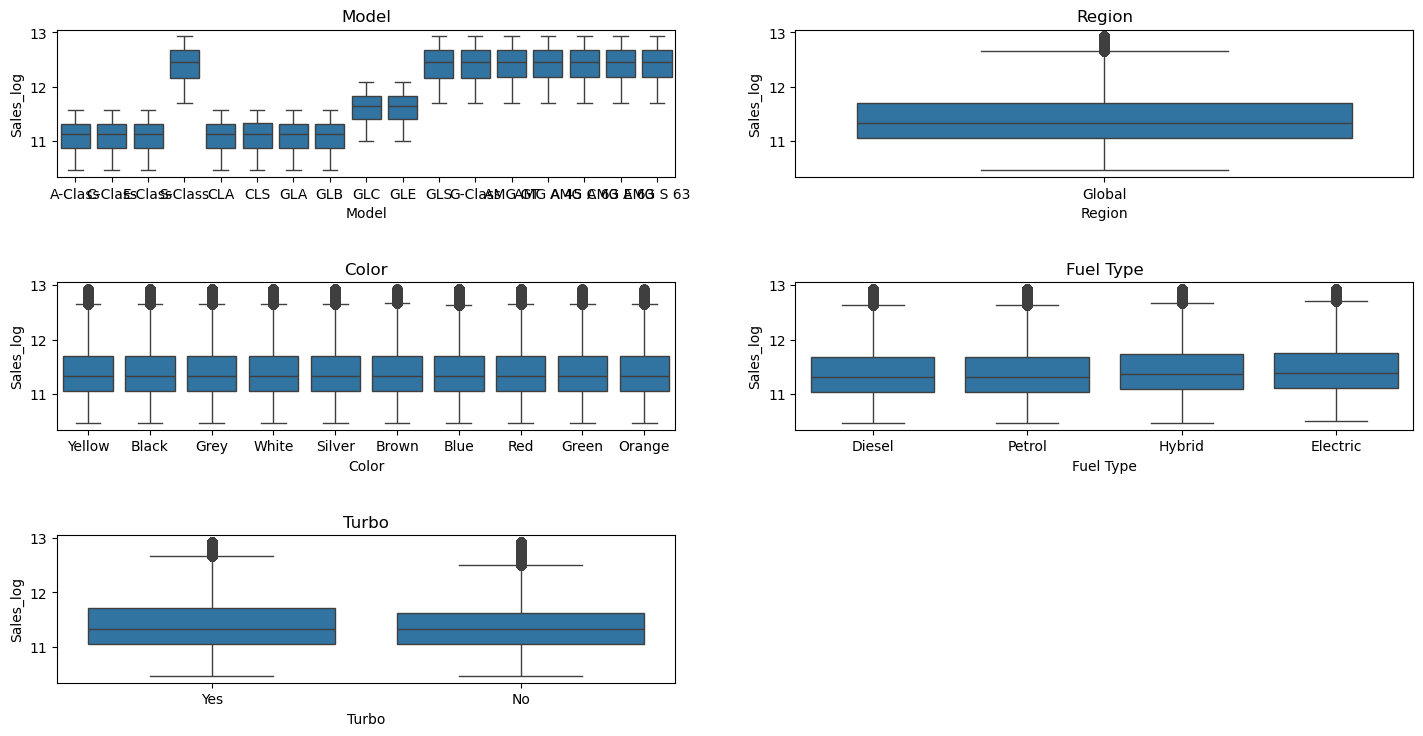

In [27]:
cat_cols = dflr.select_dtypes(include='object').columns

plt.figure(figsize=(15,8))

for i, col in enumerate(cat_cols,1):
    plt.subplot(3,2,i)
    sns.boxplot(x=dflr[col], y=dflr['Sales_log'])
    plt.title(f'{col}')

plt.tight_layout(pad=3)
plt.show()

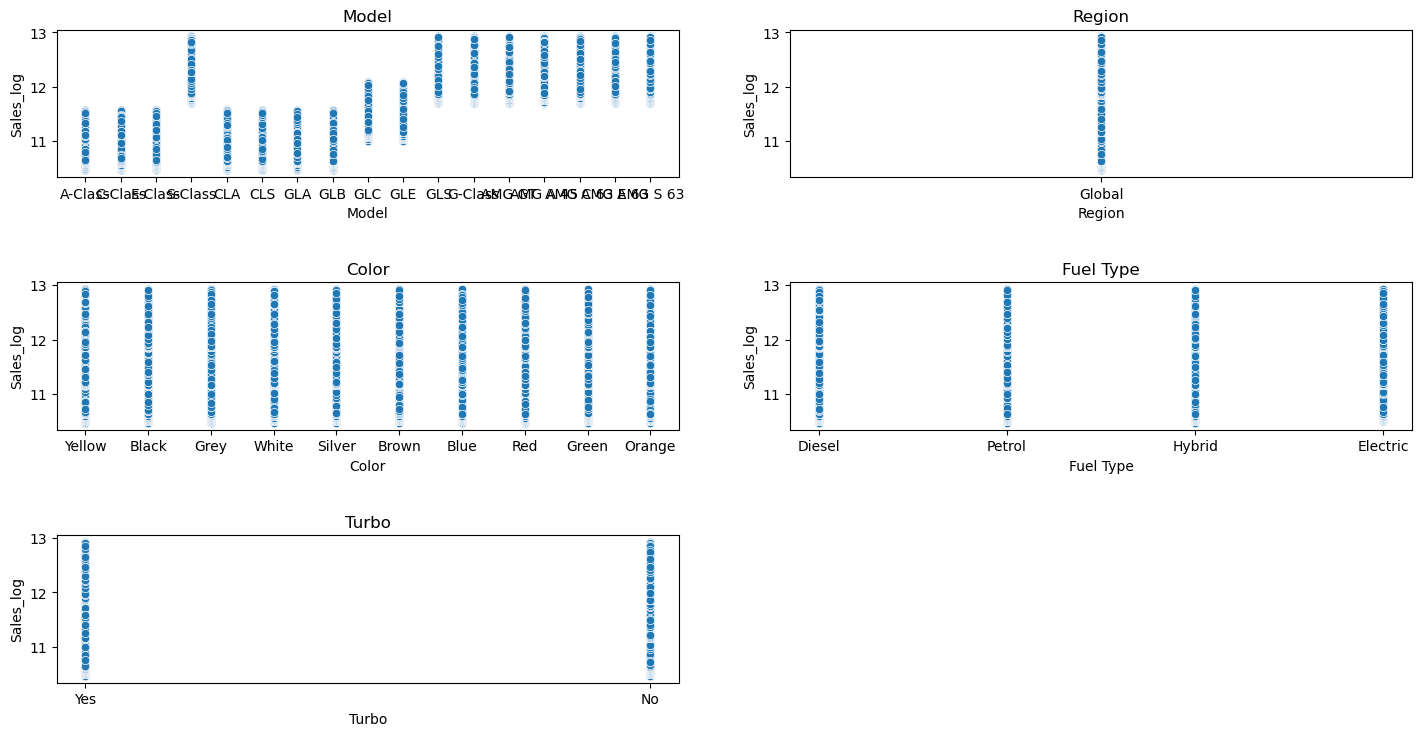

In [28]:
cat_cols = dflr.select_dtypes(include='object').columns

plt.figure(figsize=(15,8))

for i, col in enumerate(cat_cols,1):
    plt.subplot(3,2,i)
    sns.scatterplot(x=dflr[col], y=dflr['Sales_log'])
    plt.title(f'{col}')

plt.tight_layout(pad=3)
plt.show()

In [29]:
results = []

for col in cat_cols:
    n = dflr[col].nunique()
    
    if n == 2:
        groups = dflr[col].dropna().unique()
        g1 = dflr[dflr[col] == groups[0]]['Base_Price_log']
        g2 = dflr[dflr[col] == groups[1]]['Base_Price_log']
        
        stat, p = ttest_ind(g1, g2)
        test_type = 't-test'
        
    elif n > 2:
        groups = [group['Base_Price_log'].values for name, group in dflr.groupby(col)]
        stat, p = f_oneway(*groups)
        test_type = 'ANOVA'
        
    else:
        continue
    
    results.append({
        'Feature': col,
        'Test': test_type,
        'Groups': n,
        'p-value': p
    })

import pandas as pd
results_dflr = pd.DataFrame(results)
print(results_dflr.sort_values('p-value'))

     Feature    Test  Groups   p-value
0      Model   ANOVA      17  0.000000
2  Fuel Type   ANOVA       4  0.000000
3      Turbo  t-test       2  0.000000
1      Color   ANOVA      10  0.294217


In [30]:
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    
    return np.sqrt(chi2 / (n * (min(k-1, r-1))))

results = []

for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        col1 = cat_cols[i]
        col2 = cat_cols[j]
        
        # contingency table
        table = pd.crosstab(dflr[col1], dflr[col2])
        
        # chi-square
        chi2, p, dof, expected = chi2_contingency(table)
        
        # cramers v
        v = cramers_v(table)
        
        results.append({
            'Feature 1': col1,
            'Feature 2': col2,
            'Chi2 p-value': p,
            'Cramers V': v
        })

results_dflr_cscv = pd.DataFrame(results)
print(results_dflr_cscv.sort_values('Cramers V', ascending=False))

C:\Users\zuhairi\AppData\Local\Temp\ipykernel_21876\671478011.py:9: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(k-1, r-1))))
C:\Users\zuhairi\AppData\Local\Temp\ipykernel_21876\671478011.py:9: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(k-1, r-1))))
C:\Users\zuhairi\AppData\Local\Temp\ipykernel_21876\671478011.py:9: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(k-1, r-1))))
C:\Users\zuhairi\AppData\Local\Temp\ipykernel_21876\671478011.py:9: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(k-1, r-1))))


   Feature 1  Feature 2  Chi2 p-value  Cramers V
3      Model      Turbo  0.000000e+00   0.059968
2      Model  Fuel Type  2.917977e-95   0.004041
1      Model      Color  8.037841e-02   0.001242
8      Color      Turbo  1.326710e-01   0.001063
7      Color  Fuel Type  5.835344e-01   0.000826
9  Fuel Type      Turbo  5.913178e-01   0.000397
0      Model     Region  1.000000e+00        NaN
4     Region      Color  1.000000e+00        NaN
5     Region  Fuel Type  1.000000e+00        NaN
6     Region      Turbo  1.000000e+00        NaN


In [31]:
dflr[['hp_log', 'Base_Price_log']].corr()

,hp_log,Base_Price_log
hp_log,1.000000,0.400752
Base_Price_log,0.400752,1.000000


In [32]:
x = dflr[['hp_log', 'Model', 'Fuel Type', 'Turbo']]
y = dflr['Base_Price_log']

In [33]:
x.head()

,hp_log,Model,Fuel Type,Turbo
0,5.533389,A-Class,Diesel,Yes
1,5.521461,A-Class,Petrol,No
2,5.834811,A-Class,Petrol,Yes
3,5.955837,A-Class,Petrol,Yes
4,5.823046,A-Class,Petrol,Yes


In [34]:
y.head()

0    10.627794
1    10.840051
2    11.195746
3    11.042618
4    10.468517
Name: Base_Price_log, dtype: float64

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score


In [36]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [37]:
cat_col = x_train.select_dtypes(include='object').columns
num_col = x_train.select_dtypes(include=np.number).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_col),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_col)
    ]
)

In [38]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('modellr', LinearRegression())
])

pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['hp_log'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Model', 'Fuel Type', 'Turbo'], dtype='object'))])),
                ('modellr', LinearRegression())])

In [39]:
y_predlr = pipeline.predict(x_test)

print('RMSE:', root_mean_squared_error(y_test, y_predlr))
print('MAE:', mean_absolute_error(y_test, y_predlr))
print('R2:', r2_score(y_test, y_predlr))

RMSE: 0.27278128900592435
MAE: 0.23288003395203516
R2: 0.7179283890680264


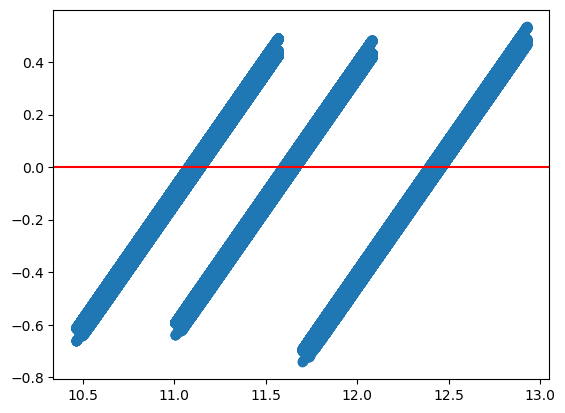

In [40]:
residual = y_test - y_predlr

plt.scatter(y_test, residual)
plt.axhline(0, color='r')

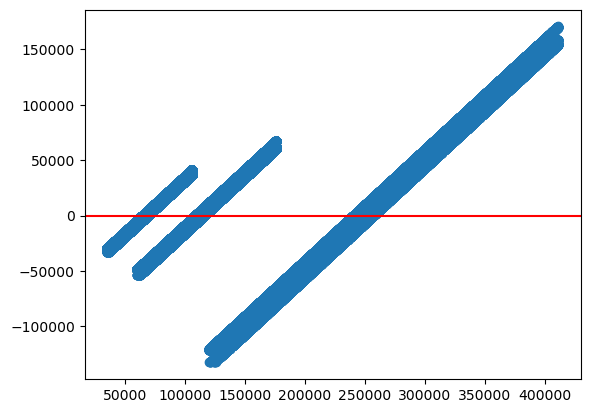

In [41]:
y_pred_real = np.exp(y_predlr)
y_test_real = np.exp(y_test)

residual_real = y_test_real - y_pred_real

plt.scatter(y_test_real, residual_real)
plt.axhline(0, color='r')

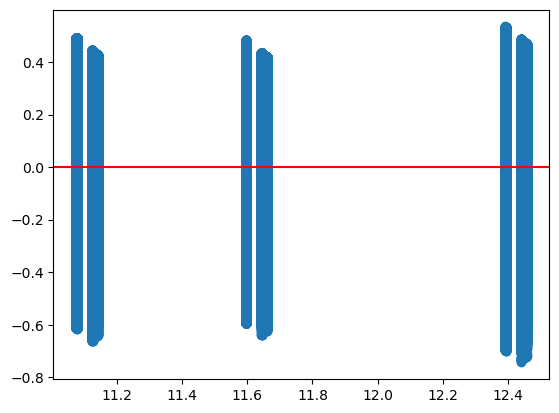

In [42]:
plt.scatter(y_predlr, residual)
plt.axhline(0, color='r')

In [43]:
import statsmodels.api as sm

x_test_transformed = pipeline[:-1].transform(x_test).toarray()

# tambah constant
x_test_transformed = sm.add_constant(x_test_transformed)

import statsmodels.stats.api as sms

test = sms.het_breuschpagan(residual, x_test_transformed)

print(test)

(19656.91275631672, 0.0, 900.7846588283942, 0.0)


### RANDOM FOREST MODEL

In [44]:
dfrf = df.copy()

In [45]:
dfrf.head()

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo,Sales
0,A-Class,2020,Global,Yellow,Diesel,41265,252,1,Yes,41265
1,A-Class,2020,Global,Black,Petrol,51023,249,1,No,51023
2,A-Class,2020,Global,Grey,Petrol,72819,341,1,Yes,72819
3,A-Class,2020,Global,Black,Petrol,62480,385,1,Yes,62480
4,A-Class,2020,Global,White,Petrol,35189,337,1,Yes,35189


In [46]:
dfrf.drop(columns=['Sales'], inplace=True)

In [47]:
dfrf.head()

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo
0,A-Class,2020,Global,Yellow,Diesel,41265,252,1,Yes
1,A-Class,2020,Global,Black,Petrol,51023,249,1,No
2,A-Class,2020,Global,Grey,Petrol,72819,341,1,Yes
3,A-Class,2020,Global,Black,Petrol,62480,385,1,Yes
4,A-Class,2020,Global,White,Petrol,35189,337,1,Yes


In [48]:
corrf = df[['Base Price (USD)', 'Horsepower']].corr(method='spearman')
corrf

,Base Price (USD),Horsepower
Base Price (USD),1.000000,0.353507
Horsepower,0.353507,1.000000


In [49]:
## sns.regplot(x=dfrf['Horsepower'], y = dfrf['Base Price (USD)'], data=dfrf, line_kws = {'color':'red'})

In [50]:
results = []

for col in dfrf.select_dtypes(include=['number']).columns:
    stat, p = shapiro(dfrf[col].dropna())
    results.append([col, p])

pd.DataFrame(results, columns=['Feature', 'p-value'])

c:\Users\zuhairi\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12132666.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\zuhairi\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


,Feature,p-value
0,Year,2.478660e-157
1,Base Price (USD),3.049697e-193
2,Horsepower,1.470310e-123
3,Sales Volume,1.000000e+00


In [51]:
for col in dfrf.select_dtypes(include=['number']).columns:
    data = dfrf[col].dropna()
    
    result = anderson(data, dist='norm')
    
    stat = result.statistic
    crit = result.critical_values
    sig = result.significance_level
    
    print(f"\nColumn: {col}")
    print(f"Statistic: {stat:.4f}")
    
    # biasanya guna level 5%
    if stat < crit[2]:  
        print("Result: Looks normal (fail to reject H0 at 5%)")
    else:
        print("Result: NOT normal (reject H0 at 5%)")


Column: Year
Statistic: 317661.3967
Result: NOT normal (reject H0 at 5%)

Column: Base Price (USD)
Statistic: 914489.8541
Result: NOT normal (reject H0 at 5%)

Column: Horsepower
Statistic: 55739.2434
Result: NOT normal (reject H0 at 5%)


c:\Users\zuhairi\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:2248: RuntimeWarning: invalid value encountered in divide
  w = (y - xbar) / s



Column: Sales Volume
Statistic: nan
Result: NOT normal (reject H0 at 5%)


In [52]:
# contoh: df anda
# pastikan target adalah numerical (contoh: 'Price')
target = 'Base Price (USD)'

# detect categorical columns
cat_cols = dfrf.select_dtypes(include=['object', 'category']).columns

# buang 'Year' kalau dia categorical (just in case)
cat_cols = [col for col in cat_cols if col != 'Year']

results = []

for col in cat_cols:
    groups = dfrf.groupby(col)[target].apply(list)
    n_groups = len(groups)

    print(f"\nColumn: {col}")
    print(f"Number of categories: {n_groups}")

    if n_groups == 2:
        # Mann-Whitney U Test
        group1, group2 = groups.iloc[0], groups.iloc[1]
        stat, p = mannwhitneyu(group1, group2)

        print("Test: Mann-Whitney U")
        print(f"Statistic: {stat}, p-value: {p}")

        results.append((col, 'Mann-Whitney', stat, p))

    elif n_groups > 2:
        # Kruskal-Wallis Test
        stat, p = kruskal(*groups)

        print("Test: Kruskal-Wallis")
        print(f"Statistic: {stat}, p-value: {p}")

        results.append((col, 'Kruskal', stat, p))

    else:
        print("Skipped (only 1 category)")

# convert to DataFrame
results_df = pd.DataFrame(results, columns=['Column', 'Test', 'Statistic', 'p-value'])
print("\nSummary:")
print(results_df)


Column: Model
Number of categories: 17
Test: Kruskal-Wallis
Statistic: 7413280.125018195, p-value: 0.0

Column: Region
Number of categories: 1
Skipped (only 1 category)

Column: Color
Number of categories: 10
Test: Kruskal-Wallis
Statistic: 12.940020256942336, p-value: 0.16533911757262976

Column: Fuel Type
Number of categories: 4
Test: Kruskal-Wallis
Statistic: 37405.44753974492, p-value: 0.0

Column: Turbo
Number of categories: 2
Test: Mann-Whitney U
Statistic: 8839966901680.0, p-value: 0.0

Summary:
      Column          Test     Statistic   p-value
0      Model       Kruskal  7.413280e+06  0.000000
1      Color       Kruskal  1.294002e+01  0.165339
2  Fuel Type       Kruskal  3.740545e+04  0.000000
3      Turbo  Mann-Whitney  8.839967e+12  0.000000


In [53]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [54]:
print(corrf.columns)

Index(['Base Price (USD)', 'Horsepower'], dtype='object')


In [55]:
xe = dfrf[['Horsepower', 'Model', 'Fuel Type', 'Turbo']]
ye = dfrf['Base Price (USD)']

In [56]:
xe.head()

,Horsepower,Model,Fuel Type,Turbo
0,252,A-Class,Diesel,Yes
1,249,A-Class,Petrol,No
2,341,A-Class,Petrol,Yes
3,385,A-Class,Petrol,Yes
4,337,A-Class,Petrol,Yes


In [57]:
ye.head()

0    41265
1    51023
2    72819
3    62480
4    35189
Name: Base Price (USD), dtype: int64

In [58]:
xe_train, xe_test, ye_train, ye_test = train_test_split(xe,ye, test_size=0.2, random_state=42)

In [59]:
cat_colsrf = xe_train.select_dtypes(include='object').columns.tolist()
num_colsrf = xe_train.select_dtypes(exclude='object').columns.tolist()

preprocessorf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_colsrf),
        ('num', 'passthrough', num_colsrf)
    ]
)



In [ ]:
import sys
print(id(num_colsrf))

In [ ]:
cat_colsrf = xe.select_dtypes(include='object').columns.tolist()
num_colsrf = xe.select_dtypes(exclude='object').columns.tolist()

print(num_colsrf)  # confirm tak ada hp_log